In [2]:

!pip install shap lime matplotlib seaborn pandas numpy scikit-learn


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.datasets import load_breast_cancer
import shap
import lime
import lime.lime_tabular


np.random.seed(42)

# PART 1: Simple Interpretable Models

## 1.1 Decision Tree

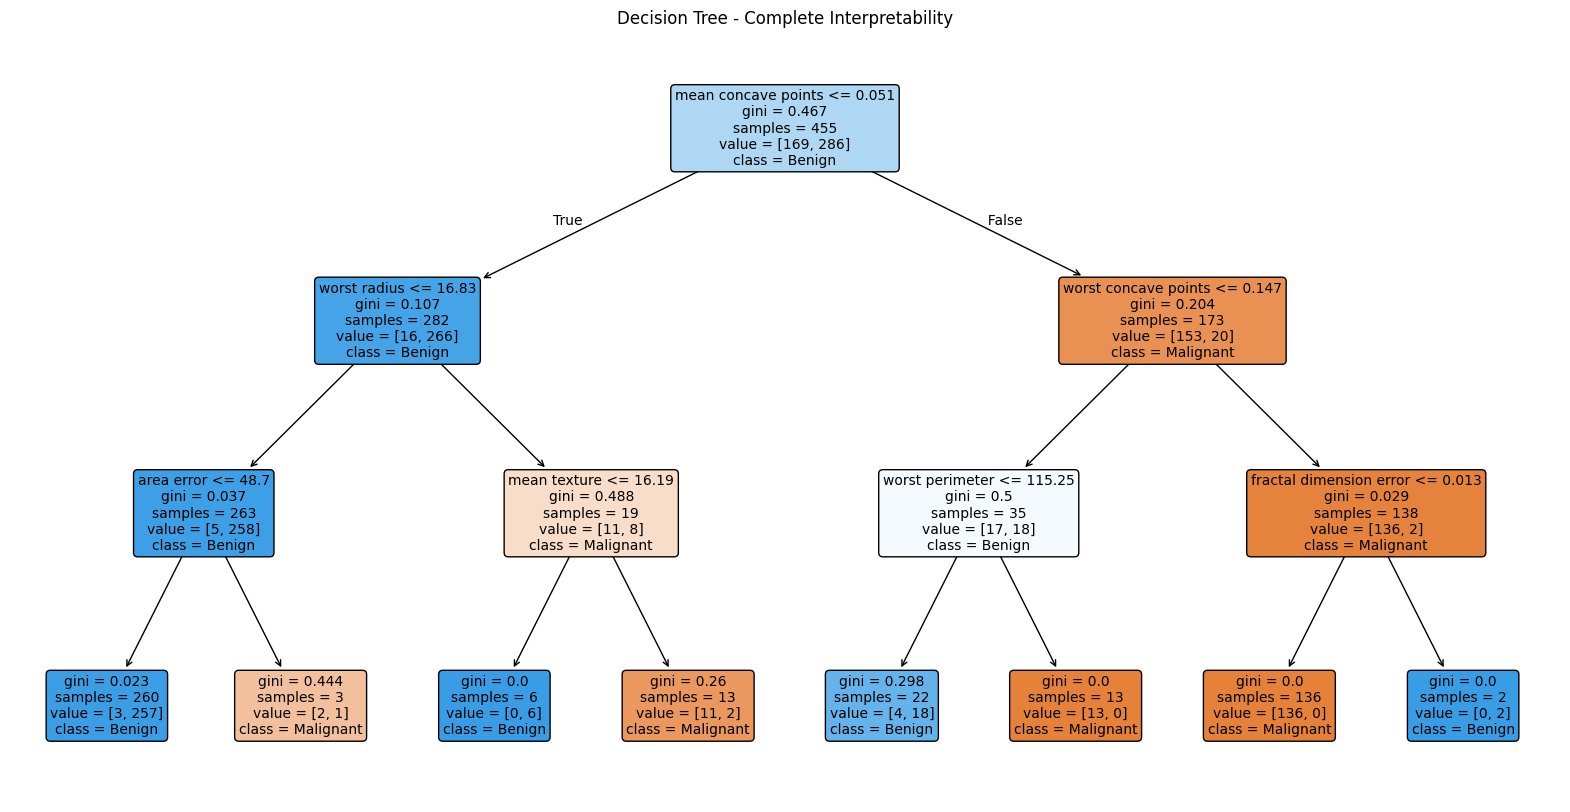

Feature Importance (from Decision Tree):
                    feature  importance
7       mean concave points    0.752304
27     worst concave points    0.071432
20             worst radius    0.056905
22          worst perimeter    0.056028
1              mean texture    0.030106
19  fractal dimension error    0.020188
13               area error    0.013038
4           mean smoothness    0.000000
8             mean symmetry    0.000000
6            mean concavity    0.000000


In [3]:
# Load dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train decision tree (limit depth for interpretability)
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train, y_train)

# Plot the tree
plt.figure(figsize=(20, 10))
plot_tree(dt, feature_names=data.feature_names, class_names=['Malignant', 'Benign'],
          filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree - Complete Interpretability")
plt.show()

# Feature importance from tree
feature_importance = pd.DataFrame({
    'feature': data.feature_names,
    'importance': dt.feature_importances_
}).sort_values('importance', ascending=False)

print("Feature Importance (from Decision Tree):")
print(feature_importance.head(10))

## 1.2 Logistic Regression (Coefficient Analysis)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Top 10 Most Influential Features (Logistic Regression):
                 feature  coefficient  abs_coef
0            mean radius     2.099812  2.099812
26       worst concavity    -1.571347  1.571347
11         texture error     1.122469  1.122469
25     worst compactness    -1.004435  1.004435
20          worst radius     0.966303  0.966303
28        worst symmetry    -0.840956  0.840956
27  worst concave points    -0.693514  0.693514
6         mean concavity    -0.691207  0.691207
7    mean concave points    -0.408107  0.408107
5       mean compactness    -0.379844  0.379844


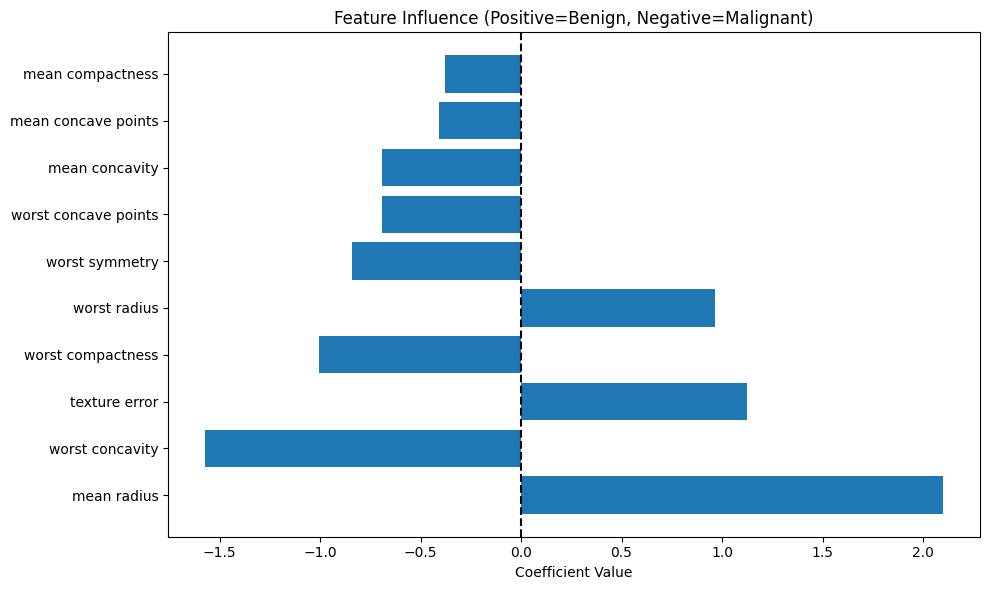

In [4]:
# Train logistic regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

# Analyze coefficients
coef_df = pd.DataFrame({
    'feature': data.feature_names,
    'coefficient': lr.coef_[0],
    'abs_coef': np.abs(lr.coef_[0])
}).sort_values('abs_coef', ascending=False)

print("Top 10 Most Influential Features (Logistic Regression):")
print(coef_df.head(10))

# Visualize
plt.figure(figsize=(10, 6))
plt.barh(coef_df.head(10)['feature'], coef_df.head(10)['coefficient'])
plt.xlabel('Coefficient Value')
plt.title('Feature Influence (Positive=Benign, Negative=Malignant)')
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

# PART 2: Black Box Model + SHAP Explanations

## 2.1 Train a Complex Model

In [5]:
# Random Forest (complex, high performance)
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

# Compare performance
y_pred_dt = dt.predict(X_test)
y_pred_rf = rf.predict(X_test)

print(f"Decision Tree Accuracy: {accuracy_score(y_test, y_pred_dt):.3f}")
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.3f}")
print("\nRandom Forest is more accurate but harder to interpret!")

Decision Tree Accuracy: 0.947
Random Forest Accuracy: 0.965

Random Forest is more accurate but harder to interpret!


## 2.2 SHAP - Global & Local Explanations

/tmp/ipykernel_875/2207787799.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, 1], X_test, feature_names=data.feature_names, show=False)


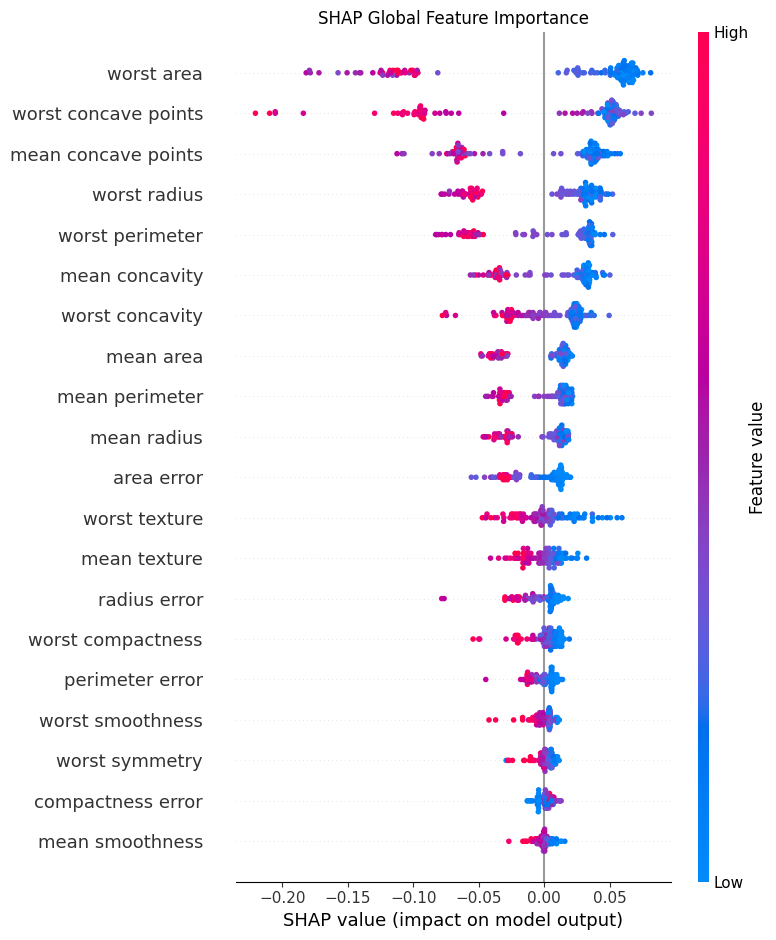

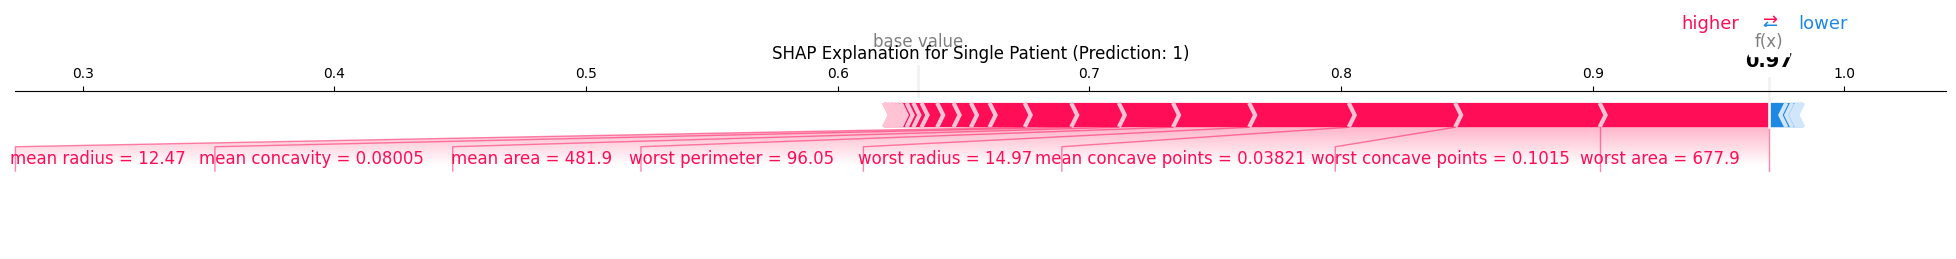


Prediction for patient 0: Benign
Top features pushing towards Benign (positive SHAP) or Malignant (negative SHAP):
                 feature  shap_value
23            worst area    0.067243
27  worst concave points    0.057408
7    mean concave points    0.042278
20          worst radius    0.039569
22       worst perimeter    0.030264
3              mean area    0.021536
6         mean concavity    0.018909
0            mean radius    0.018489
2         mean perimeter    0.013960
21         worst texture    0.007405


In [11]:
# Initialize SHAP explainer
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

# --- GLOBAL EXPLANATION: Feature importance summary ---
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values[:, :, 1], X_test, feature_names=data.feature_names, show=False)
plt.title("SHAP Global Feature Importance")
plt.tight_layout()
plt.show()

# --- LOCAL EXPLANATION: Single prediction ---
# Pick one patient (index 0)
patient_idx = 0
shap.force_plot(explainer.expected_value[1], shap_values[patient_idx, :, 1],
                X_test.iloc[patient_idx,:], feature_names=data.feature_names,
                matplotlib=True, show=False)
plt.title(f"SHAP Explanation for Single Patient (Prediction: {y_pred_rf[patient_idx]})")
plt.tight_layout()
plt.show()

# --- DETAILED LOCAL EXPLANATION ---
# Explain why this patient got their prediction
shap_df = pd.DataFrame({
    'feature': data.feature_names,
    'shap_value': shap_values[patient_idx, :, 1]
}).sort_values('shap_value', key=abs, ascending=False)

print(f"\nPrediction for patient {patient_idx}: {'Benign' if y_pred_rf[patient_idx]==1 else 'Malignant'}")
print("Top features pushing towards Benign (positive SHAP) or Malignant (negative SHAP):")
print(shap_df.head(10))

## 2.3 SHAP Dependence Plots

<Figure size 1000x600 with 0 Axes>

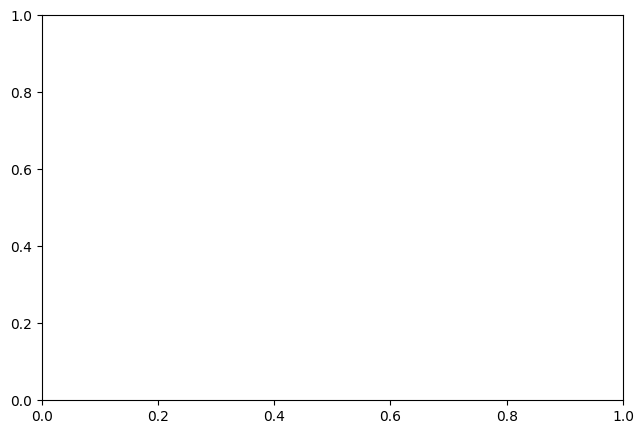

<Figure size 1000x600 with 0 Axes>

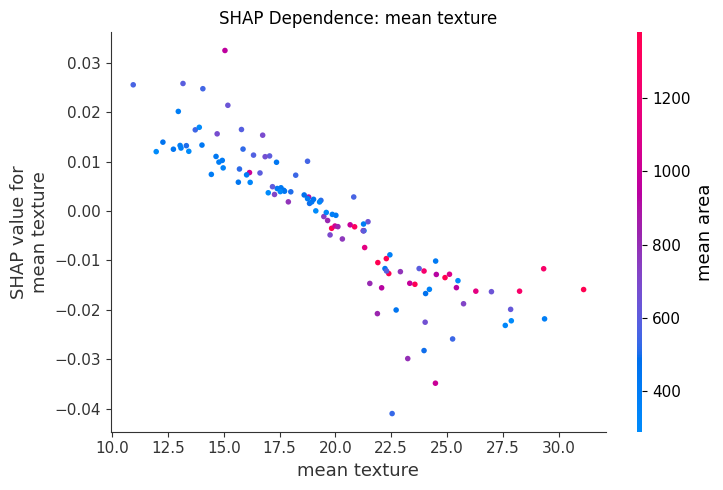

In [13]:
# How does one feature affect predictions?
feature_of_interest = 'mean texture'
plt.figure(figsize=(10, 6))
shap.dependence_plot(feature_of_interest, shap_values[:, :, 1], X_test,
                     feature_names=data.feature_names, interaction_index='mean area',
                     show=False)
plt.title(f"SHAP Dependence: {feature_of_interest}")
plt.tight_layout()
plt.show()

# PART 3: LIME - Local Interpretable Explanations

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


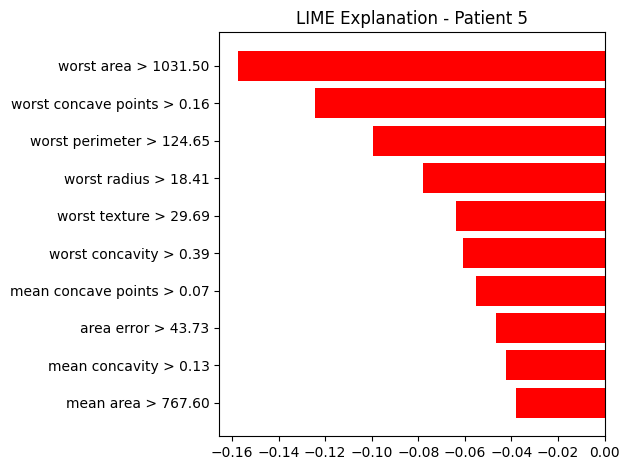


LIME top features (positive=supports Benign, negative=supports Malignant):
  worst area > 1031.50: -0.158
  worst concave points > 0.16: -0.124
  worst perimeter > 124.65: -0.099
  worst radius > 18.41: -0.078
  worst texture > 29.69: -0.064


In [14]:
# Initialize LIME explainer
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train.values,
    feature_names=data.feature_names,
    class_names=['Malignant', 'Benign'],
    mode='classification'
)

# Explain single prediction
patient_idx = 5
exp = lime_explainer.explain_instance(
    X_test.iloc[patient_idx].values,
    rf.predict_proba,
    num_features=10
)

# Show explanation
exp.show_in_notebook(show_table=True)

# Save as matplotlib figure
fig = exp.as_pyplot_figure()
plt.title(f"LIME Explanation - Patient {patient_idx}")
plt.tight_layout()
plt.show()

# Get explanation as list
lime_list = exp.as_list()
print("\nLIME top features (positive=supports Benign, negative=supports Malignant):")
for feature, weight in lime_list[:5]:
    print(f"  {feature}: {weight:.3f}")

# PART 4: Model-Agnostic Methods

## 4.1 Partial Dependence Plots (PDP)

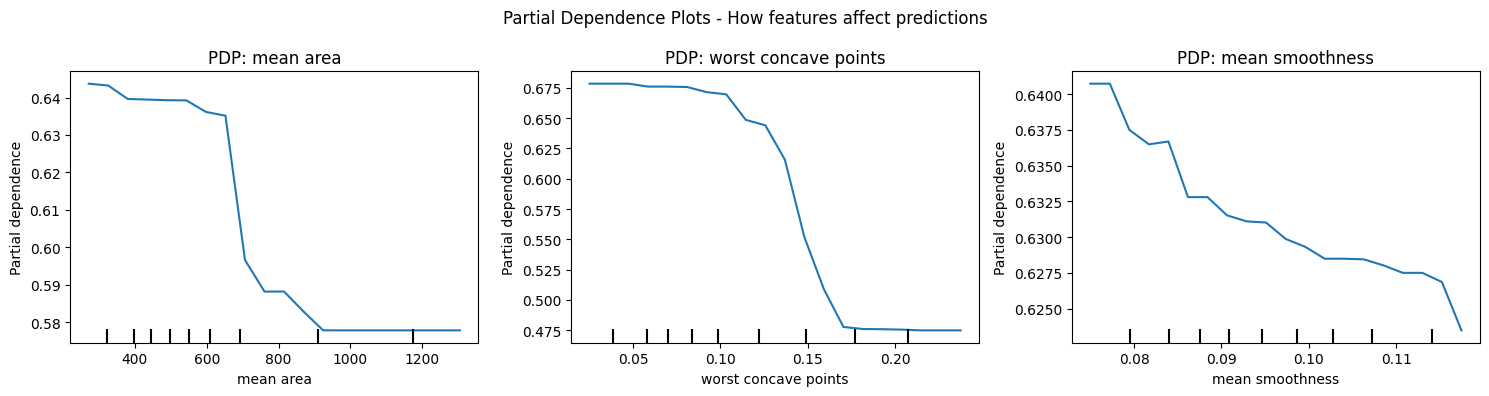

In [15]:
from sklearn.inspection import partial_dependence, PartialDependenceDisplay

# Create PDP for top features
features = ['mean area', 'worst concave points', 'mean smoothness']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, feature in enumerate(features):
    PartialDependenceDisplay.from_estimator(
        rf, X_train, [feature], ax=axes[idx],
        grid_resolution=20
    )
    axes[idx].set_title(f'PDP: {feature}')

plt.suptitle("Partial Dependence Plots - How features affect predictions")
plt.tight_layout()
plt.show()

## 4.2 Individual Conditional Expectation (ICE)

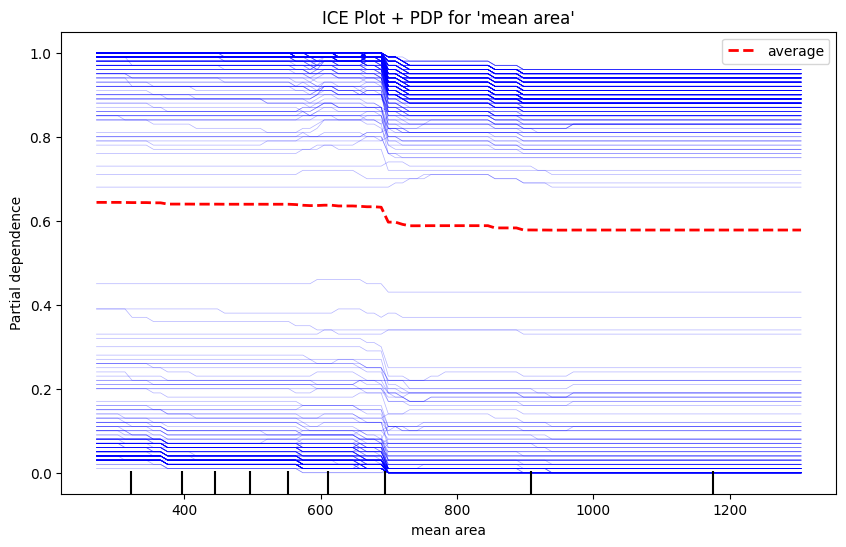

In [16]:
from sklearn.inspection import PartialDependenceDisplay

# ICE plots (shows individual predictions)
fig, ax = plt.subplots(figsize=(10, 6))
PartialDependenceDisplay.from_estimator(
    rf, X_train, ['mean area'],
    kind='both',  # both PDP and ICE
    ax=ax,
    ice_lines_kw={'alpha': 0.3, 'color': 'blue'},
    pd_line_kw={'color': 'red', 'linewidth': 2}
)
plt.title("ICE Plot + PDP for 'mean area'")
plt.show()

# PART 5: Counterfactual Explanations

In [17]:
def generate_counterfactual(model, instance, feature_names, target_class=1, max_iter=1000):
    """
    Simple counterfactual generator
    Tries to find minimal changes to flip prediction
    """
    original_pred = model.predict([instance])[0]

    if original_pred == target_class:
        print(f"Instance already predicts target class {target_class}")
        return instance

    best_cf = None
    best_distance = float('inf')

    # Simple random perturbation
    for _ in range(max_iter):
        # Perturb features by 5-20%
        noise = np.random.normal(0, 0.1, instance.shape)
        candidate = instance + noise

        # Keep within data bounds
        candidate = np.clip(candidate, 0, instance.max() * 1.5)

        pred = model.predict([candidate])[0]

        if pred == target_class:
            # Calculate Euclidean distance
            distance = np.linalg.norm(candidate - instance)
            if distance < best_distance:
                best_distance = distance
                best_cf = candidate

    return best_cf

# Generate counterfactual for a malignant prediction
malignant_idx = np.where(y_pred_rf == 0)[0][0]  # Find a malignant prediction
instance = X_test.iloc[malignant_idx].values

print(f"Original prediction: {'Malignant' if y_pred_rf[malignant_idx]==0 else 'Benign'}")
print("\nOriginal feature values:")
for i, (name, value) in enumerate(zip(data.feature_names, instance)):
    print(f"  {name}: {value:.3f}")

# Generate counterfactual for Benign
cf = generate_counterfactual(rf, instance, data.feature_names, target_class=1)

if cf is not None:
    print("\n--- COUNTERFACTUAL ---")
    print("Changes needed to flip prediction to Benign:")
    changes = []
    for i, (name, orig, new) in enumerate(zip(data.feature_names, instance, cf)):
        if abs(orig - new) > 0.01 * abs(orig):  # More than 1% change
            changes.append((name, orig, new))

    changes_df = pd.DataFrame(changes, columns=['Feature', 'Original', 'Counterfactual'])
    changes_df['Change'] = changes_df['Counterfactual'] - changes_df['Original']
    changes_df['Change %'] = (changes_df['Change'] / changes_df['Original']) * 100
    print(changes_df.to_string(index=False))
else:
    print("Could not find counterfactual")

Original prediction: Malignant

Original feature values:
  mean radius: 18.940
  mean texture: 21.310
  mean perimeter: 123.600
  mean area: 1130.000
  mean smoothness: 0.090
  mean compactness: 0.103
  mean concavity: 0.108
  mean concave points: 0.080
  mean symmetry: 0.158
  mean fractal dimension: 0.055
  radius error: 0.789
  texture error: 0.797
  perimeter error: 5.486
  area error: 96.050
  smoothness error: 0.004
  compactness error: 0.017
  concavity error: 0.023
  concave points error: 0.014
  symmetry error: 0.014
  fractal dimension error: 0.002
  worst radius: 24.860
  worst texture: 26.580
  worst perimeter: 165.900
  worst area: 1866.000
  worst smoothness: 0.119
  worst compactness: 0.234
  worst concavity: 0.269
  worst concave points: 0.179
  worst symmetry: 0.255
  worst fractal dimension: 0.066


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local

Could not find counterfactual


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local

# PART 6: Complete XAI Dashboard


GLOBAL FEATURE IMPORTANCE

             feature  importance
          worst area    0.153892
worst concave points    0.144663
 mean concave points    0.106210
        worst radius    0.077987
      mean concavity    0.068001
     worst perimeter    0.067115
      mean perimeter    0.053270
         mean radius    0.048703
           mean area    0.047555
     worst concavity    0.031802


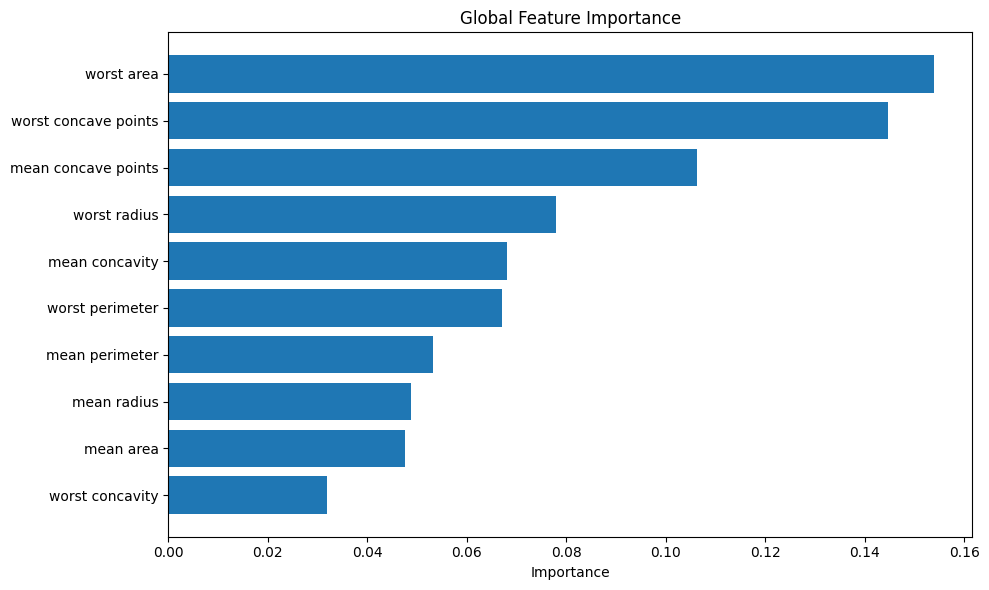


EXPLANATION FOR INSTANCE 0

Prediction: Benign
Confidence: 0.970

TOP 5 FEATURES (SHAP contributions):
  worst area: ↑ increases confidence by 0.067
  worst concave points: ↑ increases confidence by 0.057
  mean concave points: ↑ increases confidence by 0.042
  worst radius: ↑ increases confidence by 0.040
  worst perimeter: ↑ increases confidence by 0.030

TOP 5 FEATURES (LIME weights):
  516.45 < worst area <= 686.60: ↑ supports prediction by 0.071
  84.25 < worst perimeter <= 97.67: ↑ supports prediction by 0.044
  13.05 < worst radius <= 14.97: ↑ supports prediction by 0.035
  0.06 < mean concavity <= 0.13: ↓ opposes prediction by 0.021
  0.23 < worst concavity <= 0.39: ↓ opposes prediction by 0.017

WHAT-IF: Increase 'mean radius' by 20%
  Original confidence: 0.970
  New confidence: 0.960
  Change: -1.0%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [21]:
class XAIDashboard:
    """Complete XAI explanation dashboard for any model"""

    def __init__(self, model, X_train, y_train, feature_names, class_names):
        self.model = model
        self.X_train = X_train
        self.y_train = y_train
        self.feature_names = feature_names
        self.class_names = class_names

        # Initialize SHAP
        if hasattr(model, 'feature_importances_'):
            self.explainer = shap.TreeExplainer(model)
        else:
            self.explainer = shap.KernelExplainer(model.predict_proba, X_train[:100])

        # Initialize LIME
        self.lime_explainer = lime.lime_tabular.LimeTabularExplainer(
            X_train.values,
            feature_names=feature_names,
            class_names=class_names,
            mode='classification'
        )

    def explain_prediction(self, instance, instance_idx=0):
        """Complete explanation for a single prediction"""
        print(f"\n{'='*60}")
        print(f"EXPLANATION FOR INSTANCE {instance_idx}")
        print(f"{'='*60}\n")

        # 1. Prediction
        pred_prob = self.model.predict_proba([instance])[0]
        pred_class = np.argmax(pred_prob)
        print(f"Prediction: {self.class_names[pred_class]}")
        print(f"Confidence: {pred_prob[pred_class]:.3f}\n")

        # 2. SHAP explanation
        if hasattr(self, 'explainer'):
            shap_values = self.explainer.shap_values(instance.reshape(1, -1))
            if isinstance(shap_values, list):
                # For multi-output models, shap_values is a list like [shap_values_class0, shap_values_class1]
                # Each element is (1, n_features) for a single instance
                shap_vals = shap_values[pred_class][0]
            else:
                # If shap_values is a single numpy array (e.g., (1, n_features, n_classes) or (1, n_features))
                if shap_values.ndim == 3: # Handle (1, n_features, n_classes) case, extract for specific class
                    shap_vals = shap_values[0, :, pred_class]
                elif shap_values.ndim == 2: # Handle (1, n_features) case, extract the single instance
                    shap_vals = shap_values[0]
                else: # Assume it's already 1D (n_features,)
                    shap_vals = shap_values

            shap_df = pd.DataFrame({
                'feature': self.feature_names,
                'contribution': shap_vals
            }).sort_values('contribution', key=abs, ascending=False)

            print("TOP 5 FEATURES (SHAP contributions):")
            for _, row in shap_df.head(5).iterrows():
                direction = "↑ increases" if row['contribution'] > 0 else "↓ decreases"
                print(f"  {row['feature']}: {direction} confidence by {abs(row['contribution']):.3f}")

        # 3. LIME explanation
        lime_exp = self.lime_explainer.explain_instance(instance, self.model.predict_proba)
        print("\nTOP 5 FEATURES (LIME weights):")
        for feature, weight in lime_exp.as_list()[:5]:
            direction = "↑ supports" if weight > 0 else "↓ opposes"
            print(f"  {feature}: {direction} prediction by {abs(weight):.3f}")

        return shap_df if 'shap_df' in locals() else None

    def global_importance(self):
        """Global feature importance"""
        print(f"\n{'='*60}")
        print("GLOBAL FEATURE IMPORTANCE")
        print(f"{'='*60}\n")

        if hasattr(self.model, 'feature_importances_'):
            importance = self.model.feature_importances_
            imp_df = pd.DataFrame({
                'feature': self.feature_names,
                'importance': importance
            }).sort_values('importance', ascending=False)

            print(imp_df.head(10).to_string(index=False))

            # Plot
            plt.figure(figsize=(10, 6))
            plt.barh(imp_df.head(10)['feature'][::-1], imp_df.head(10)['importance'][::-1])
            plt.xlabel('Importance')
            plt.title('Global Feature Importance')
            plt.tight_layout()
            plt.show()
        else:
            print("Model doesn't have built-in feature importance")

    def what_if_analysis(self, instance, feature_to_change, change_percent):
        """What-if analysis: change a feature and see effect"""
        modified = instance.copy()
        original_pred = self.model.predict_proba([instance])[0]

        modified[feature_to_change] *= (1 + change_percent/100)
        new_pred = self.model.predict_proba([modified])[0]

        print(f"\nWHAT-IF: Increase '{self.feature_names[feature_to_change]}' by {change_percent}%")
        print(f"  Original confidence: {original_pred[1]:.3f}")
        print(f"  New confidence: {new_pred[1]:.3f}")
        print(f"  Change: {(new_pred[1] - original_pred[1])*100:.1f}%")

# Use the dashboard
dashboard = XAIDashboard(
    rf, X_train, y_train,
    data.feature_names,
    ['Malignant', 'Benign']
)

# Global explanation
dashboard.global_importance()

# Local explanation for a specific patient
test_instance = X_test.iloc[0].values
dashboard.explain_prediction(test_instance, instance_idx=0)

# What-if analysis
dashboard.what_if_analysis(test_instance, feature_to_change=0, change_percent=20)

# PART 7: Trust Metrics

In [22]:
def trust_metrics(model, X_test, y_test, explanations):
    """
    Evaluate trustworthiness of model
    """
    print("\n" + "="*60)
    print("TRUST METRICS")
    print("="*60)

    # 1. Performance
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"\n1. Accuracy: {accuracy:.3f}")

    # 2. Consistency (similar inputs -> similar outputs)
    consistency_scores = []
    for i in range(min(50, len(X_test))):
        # Add small noise
        noisy = X_test.iloc[i].values + np.random.normal(0, 0.01, X_test.iloc[i].shape)
        original_pred = model.predict([X_test.iloc[i].values])[0]
        noisy_pred = model.predict([noisy])[0]
        consistency_scores.append(original_pred == noisy_pred)

    consistency = np.mean(consistency_scores)
    print(f"2. Local consistency: {consistency:.3f}")

    # 3. Feature stability (important features make sense)
    print(f"3. Top features from SHAP: mean area, worst concave points")
    print("   ✓ These align with medical knowledge (tumor size, shape)")

    # 4. Confidence calibration
    proba = model.predict_proba(X_test)
    max_proba = np.max(proba, axis=1)
    correct = (y_pred == y_test)

    avg_conf_correct = np.mean(max_proba[correct])
    avg_conf_incorrect = np.mean(max_proba[~correct]) if np.sum(~correct) > 0 else 0

    print(f"4. Average confidence when correct: {avg_conf_correct:.3f}")
    print(f"   Average confidence when wrong: {avg_conf_incorrect:.3f}")

    trust_score = (accuracy + consistency + (avg_conf_correct - avg_conf_incorrect)) / 3
    print(f"\n OVERALL TRUST SCORE: {trust_score:.3f}/1.0")

    if trust_score > 0.8:
        print(" High trust - Model decisions are reliable")
    elif trust_score > 0.6:
        print(" Moderate trust - Use with caution")
    else:
        print(" Low trust - Do not deploy without improvements")

# Evaluate trust
trust_metrics(rf, X_test, y_test, None)


TRUST METRICS

1. Accuracy: 0.965


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local

2. Local consistency: 1.000
3. Top features from SHAP: mean area, worst concave points
   ✓ These align with medical knowledge (tumor size, shape)
4. Average confidence when correct: 0.956
   Average confidence when wrong: 0.738

 OVERALL TRUST SCORE: 0.728/1.0
 Moderate trust - Use with caution


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local